In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# df = pd.read_csv('https://raw.githubusercontent.com/danielveazey/genderbyname/master/names_genders.csv')
df = pd.read_csv("data.csv")

In [3]:
df.head()

,Name,Gender,Count,Probability
0,James,M,5304407,0.014517
1,John,M,5260831,0.014398
2,Robert,M,4970386,0.013603
3,Michael,M,4579950,0.012534
4,William,M,4226608,0.011567


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147269 entries, 0 to 147268
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Name         147269 non-null  object 
 1   Gender       147269 non-null  object 
 2   Count        147269 non-null  int64  
 3   Probability  147269 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.5+ MB


In [5]:
df.isnull().sum()

Name           0
Gender         0
Count          0
Probability    0
dtype: int64

In [6]:
df["name_lower"] = df["Name"].astype(str).str.lower()
df["last_letter"] = df["name_lower"].str[-1]
df["first_letter"] = df["name_lower"].str[0]
df["length"] = df["name_lower"].apply(len)
df["vowel_count"] = df["name_lower"].apply(lambda x : sum(1 for c in x if c in 'aeiou'))

In [7]:
df.head()

,Name,Gender,Count,Probability,name_lower,last_letter,first_letter,length,vowel_count
0,James,M,5304407,0.014517,james,s,j,5,2
1,John,M,5260831,0.014398,john,n,j,4,1
2,Robert,M,4970386,0.013603,robert,t,r,6,2
3,Michael,M,4579950,0.012534,michael,l,m,7,3
4,William,M,4226608,0.011567,william,m,w,7,3


In [8]:
df.isnull().sum()

Name            0
Gender          0
Count           0
Probability     0
name_lower      0
last_letter     0
first_letter    0
length          0
vowel_count     0
dtype: int64

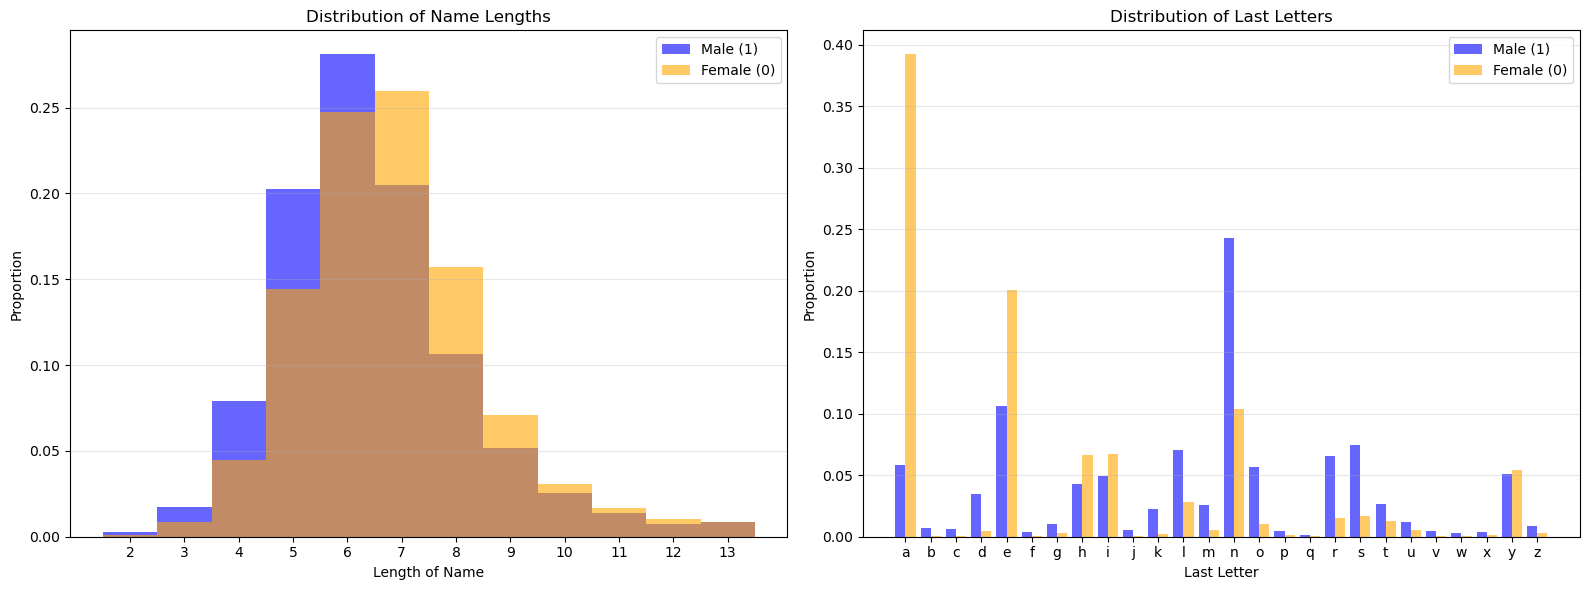

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

bins = range(2, 15)

ax1.hist(df[df['Gender'] == 'M']['length'], bins=bins, alpha=0.6, color='blue', label='Male (1)', density=True, align='left')
ax1.hist(df[df['Gender'] == 'F']['length'], bins=bins, alpha=0.6, color='orange', label='Female (0)', density=True, align='left')
ax1.set_title('Distribution of Name Lengths')
ax1.set_xlabel('Length of Name')
ax1.set_ylabel('Proportion')
ax1.set_xticks(bins[:-1])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

alphabet = 'abcdefghijklmnopqrstuvwxyz'

male_letter_counts = df[df['Gender'] == 'M']['last_letter'].value_counts()
female_letter_counts = df[df['Gender'] == 'F']['last_letter'].value_counts()

male_probs = [male_letter_counts.get(letter, 0) / len(df[df['Gender'] == 'M']) for letter in alphabet]
female_probs = [female_letter_counts.get(letter, 0) / len(df[df['Gender'] == 'F']) for letter in alphabet]

x = np.arange(len(alphabet))
width = 0.40

ax2.bar(x - width/2, male_probs, width, label='Male (1)', color='blue', alpha=0.6)
ax2.bar(x + width/2, female_probs, width, label='Female (0)', color='orange', alpha=0.6)

ax2.set_title('Distribution of Last Letters')
ax2.set_xlabel('Last Letter')
ax2.set_ylabel('Proportion')
ax2.set_xticks(x)
ax2.set_xticklabels(list(alphabet))
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

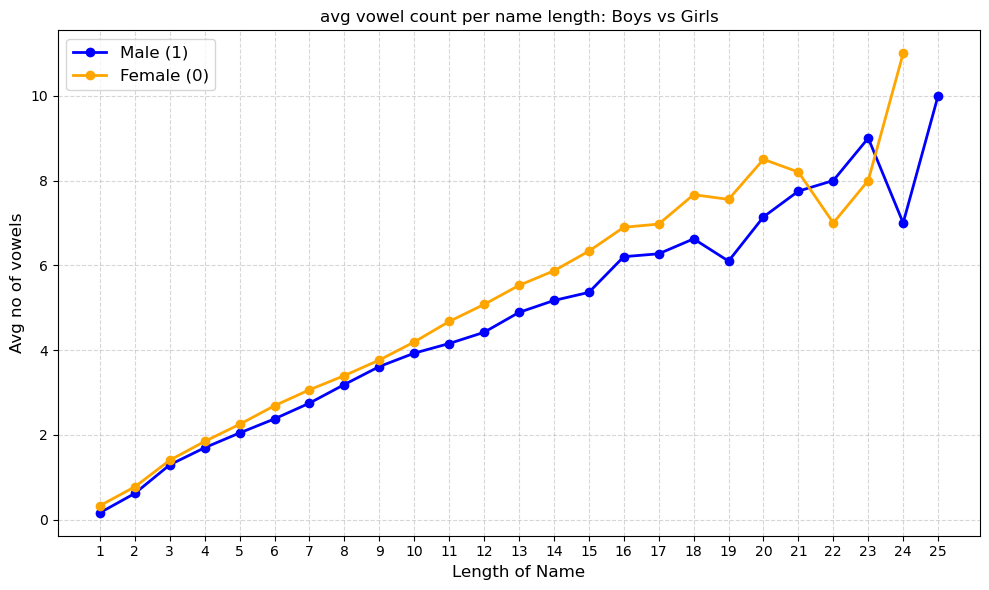

In [10]:
vowels = df.groupby(['length', 'Gender'])['vowel_count'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(vowels.index, vowels['M'], marker='o', color='blue', label='Male (1)', linewidth=2)
ax.plot(vowels.index, vowels['F'], marker='o', color='orange', label='Female (0)', linewidth=2)

ax.set_title("avg vowel count per name length: Boys vs Girls")
ax.set_xlabel("Length of Name", fontsize=12)
ax.set_ylabel("Avg no of vowels", fontsize=12)
ax.set_xticks(vowels.index)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5) 

plt.tight_layout()
plt.show()

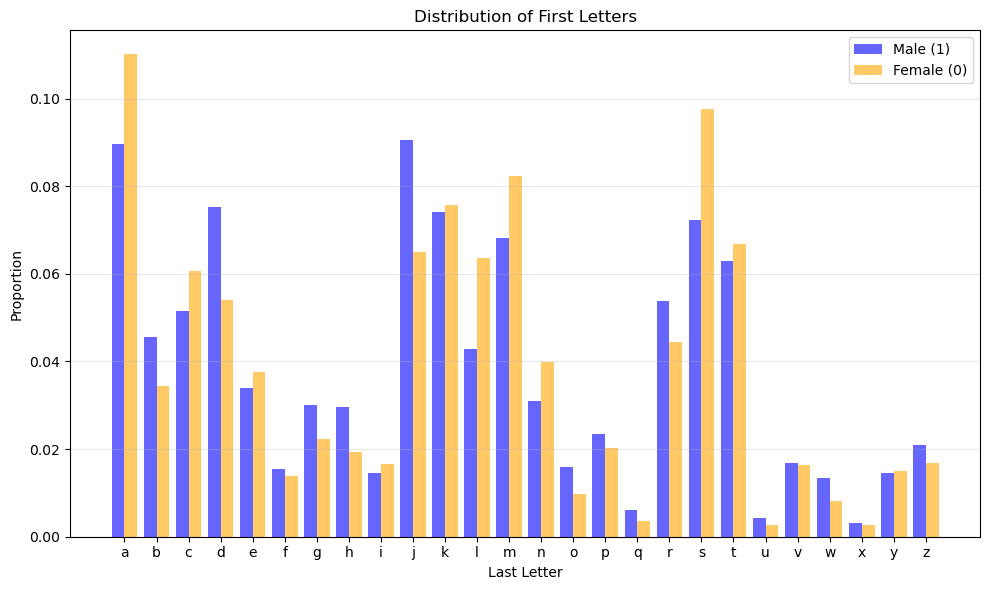

In [11]:
fig, ax2 = plt.subplots(figsize=(10, 6))

alphabet = 'abcdefghijklmnopqrstuvwxyz'

male_letter_counts = df[df['Gender'] == 'M']['first_letter'].value_counts()
female_letter_counts = df[df['Gender'] == 'F']['first_letter'].value_counts()

male_probs = [male_letter_counts.get(letter, 0) / len(df[df['Gender'] == 'M']) for letter in alphabet]
female_probs = [female_letter_counts.get(letter, 0) / len(df[df['Gender'] == 'F']) for letter in alphabet]

x = np.arange(len(alphabet))
width = 0.40

ax2.bar(x - width/2, male_probs, width, label='Male (1)', color='blue', alpha=0.6)
ax2.bar(x + width/2, female_probs, width, label='Female (0)', color='orange', alpha=0.6)

ax2.set_title('Distribution of First Letters')
ax2.set_xlabel('Last Letter')
ax2.set_ylabel('Proportion')
ax2.set_xticks(x)
ax2.set_xticklabels(list(alphabet))
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()